<a href="https://colab.research.google.com/github/RojasG4mer/Fundamentos-de-Procesamiento-Digital-de-Imagenes/blob/main/Analisis_en_el_dominio_de_las_frecuencias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from google.colab.patches import cv2_imshow

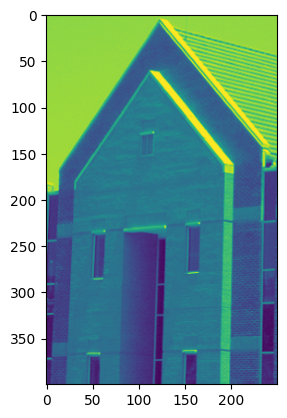

In [ ]:
ruta = '/content/drive/MyDrive/Procesamiento Digital del Imágenes/Imagenes/Casa con bordes.tif' # Casa con bordes
# '/content/drive/MyDrive/Procesamiento Digital del Imágenes/Imagenes/figuras.BMP' # Figuras
ima = cv2.imread(ruta)
ima = cv2.cvtColor(ima, cv2.COLOR_BGR2GRAY)
ima = ima[200:, 100:350]
plt.imshow(ima)

In [ ]:
print(ima.shape)

(600, 600)


# Transformada de Fourier
Cualquier función que se repite periódicamente puede ser expresada como la suma de senos y cosenos de diferentes frecuencias cada uno multiplicado por un  coeficiente diferente.

Este se usa para aplicar filtros para eliminar el ruido en ciertas frecuencias (altas o bajas).


## Definición (Continua)
Se define como:
$$ F(u) = \int_{\infty}ˆ{\infty} f(x) eˆ{-j2\pi ux} dx $$
Transformada inversa de Fourier:
$$ f(x) = \int_{\infty}ˆ{\infty} F(u) eˆ{-j2\pi ux} du $$

### Convolución y transformada de Fourier (Propiedades)
Spacial domain (x) $\iff$ Frequency domain (u):
$$ g = f*h \iff G = FH$$
$$ g = fh \iff G = F*H$$

H es un filtro (funciones que atenuan la imagen).

### Propiedades de la transformada de Fourier:

*   Linearity
*   Scaling
*   Shifting
*   Symmetry
*   Conjugation
*   Convolution
*   Diferentiation


Transformada rápida de Fourier



## Transformada de Fourier bidimensional y su inversa:

$$ F(u, v) = \iint_{\infty}ˆ{\infty} $$

## Definición (Discreta)
Una función continua $f(x)$ se discretiza

Trans discreta
$$ F(u) = \frac{1}{M} \sum_{x=0}^{M-1} f(x)e^{-j2\pi ux/M} $$
Para $u = 1, 2, ..., M-1$
AntiTrans discreta
$$ F(u) = \frac{1}{M} \sum_{x=0}^{M-1} f(x)e^{-j2\pi ux/M} $$
Para $u = 1, 2, ..., M-1$

Recordando la identidad de Euler para los complejos, podemos descomponer la señal en una parte imaginario y real:
$$ F(u) = \frac{1}{M} \sum_{x=0}^{M-1} f(x)[\cos(2\pi ux/M) - j\sin(2\pi ux/M)] $$
Lo que debemos obtener para la imagen necesitamos elevar al cuadrado los términos.

La magnitud (espectro) de la imagen es:
$$ |F(u)| = [R^2(u) + I^2(u)]^{1/2} $$
El ángulo de fase del espectro viene dado por:
$$ \phi $$

Para el caso bidimensional será:
$$ F(u, v) = \sum_{x=0}^{M-1}\sum_{y=0}^{N-1} f(x, y) e^{-j2\pi(ux/M + vy/N)} $$
Para la T. Inversa:
$$ f(x, y) = \frac{1}{MN} \sum_{u=0}^{M-1}\sum_{v=0}^{N-1} F(u, v)e^{-j2\pi(ux/M + vy/N)} $$


### Fourier y su espectro.

#### Transformada de un cuadrado
Ya que la TF del cuadrado

## TAREA
Tomar una imagen (reducirla en el tamaño para que no tarde mucho) y aplicarle trans de fourier


In [ ]:
def dft_2d_manual(imagen):
    """
    Calcula la Transformada de Fourier Discreta 2D paso a paso según la fórmula matemática.
    """
    # 1. Obtenemos las dimensiones de la imagen: M (filas) y N (columnas)
    M, N = imagen.shape

    # 2. Creamos una matriz vacía para guardar los resultados F(u, v).
    # Debe ser de tipo complejo (complex) porque la fórmula usa números imaginarios.
    F = np.zeros((M, N), dtype=complex)

    # 3. Iteramos sobre cada frecuencia u (eje vertical) y v (eje horizontal)
    for u in range(M):
        for v in range(N):

            suma_compleja = 0

            # 4. Iteramos sobre cada píxel de la imagen original f(x,y)
            for x in range(M):
                for y in range(N):

                    # Obtenemos el valor del píxel en la posición (x, y)
                    f_xy = imagen[x, y]

                    # Calculamos el exponente: -j * 2 * pi * (ux/M + vy/N)
                    # Nota: En Python, el número imaginario 'j' se escribe como '1j'
                    exponente = -1j * 2 * np.pi * ((u * x) / M + (v * y) / N)

                    # Calculamos f(x,y) * e^(exponente) y lo añadimos a la sumatoria
                    suma_compleja += f_xy * np.exp(exponente)

            # 5. Guardamos el resultado final de las sumatorias en F(u, v)
            F[u, v] = suma_compleja

    return F

In [ ]:
transformada_manual = dft_2d_manual(ima)

# Aunque hicimos la DFT manual, usaremos estas dos funciones para centrarla
# y prepararla visualmente, tal como lo hicimos en el ejemplo anterior.
transformada_centrada = np.fft.fftshift(transformada_manual)
espectro_magnitud = np.log(np.abs(transformada_centrada) + 1)

# Visualizamos el resultado
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(ima, cmap='gray')
plt.title('Imagen Original 8x8 $f(x, y)$')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(espectro_magnitud, cmap='gray')
plt.title('Espectro Manual $F(u, v)$')
plt.axis('off')

plt.show()

KeyboardInterrupt: 

# Tipos de filtro
1. Dominio espacial - convolución
$$g(x) = h(x, y) * f(x, y) $$
2. Dominio de la frecuencia -


# Algoritmo para aplicar DFT en una imagen
1. APlicar la TF en la imagen
2. Multiplicar F por H (filtro en la frecuencia)
3. Aplicar la antitransformada de Fourier a este producto
4. Aplicar un postprocesamiento para mejorar los detalles de la imagen (normalizar, escalar para 255, etc)


## Ideal Low pass filter
Corta las componentes de las altas frecuencias que están en cierta distancia $D_0$ del origen de la transformación.
La ecuación está dada por:
$$ H(u, v) = \begin{cases} 1 \text{ if } D(u, v) \leq D_{0}\\
0 \text{ if } D(u, v) > D_0
\end{cases} $$


